# Continuous Wave Analysis of NANOGrav 15-year dataset

This notebook reproduces (some) results from the NANOGrav 15-year CW analysis.

Note: in order to compare our results with [QuickCW](https://github.com/nanograv/QuickCW), we use a CURN GWB model. That is, inter-pulsar correlations are neglected in the background. However, **Prometheus** is able to efficiently sample a joint model including HD-correlations. Simply change the correlation matrix from 'CURN' to 'HD' in the `CommonSpectralModel` object!

### Requirements

- This notebook should be executed on a (NVIDIA) GPU with CUDA-enabled JAX.

- The analysis requires the packages imported in the following cell, and other common packages.

- By default, single precision (`float32`) is used. If desired, use double precision by modifying the `__init__.py` file, but this slows down the analysis.

In [13]:
# to load/save objects
import pickle
import h5py

# for plotting
import numpy as np
from iris import Iris, quickCW

# for sampling
import jax
import jax.numpy as jnp
import jax.random as jr
import numpyro

# prometheus objects
from prometheus.spectral_models import IndependentSpectralModel, CommonSpectralModel
from prometheus import spectra
from prometheus.deterministic_models import DeterministicModel
from prometheus import deterministic
from prometheus.pta_model import PTAModel
from prometheus import utilities as utils
from prometheus import posterior

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# check that we are running on a GPU
# this should print something like "CudaDevice(id=...)"
print(jax.devices())

[CudaDevice(id=0), CudaDevice(id=1)]


## Load Data

Load the NANOGrav 15-year data set as a `Prometheus.data.Data` object. The `gwb_pe.ipynb` notebook constructs and saves this object.

In [3]:
# load previously constructed data object
with open('../data/NG15/data.pkl', 'rb') as fp:
    NG15_data = pickle.load(fp)

## Construct Spectral Models

**Prometheus** requires two spectral models to perform parameter estimation:

1) `prometheus.spectral_models.IndependentSpectralModel`: 
- This corresponds to the intrinsic pulsar noise model.
- It assumes the same spectral model (e.g. power law) is applied independently to every pulsar in the array.

2) `prometheus.spectral_models.CommonSpectralModel`:
- This corresponds to a gravitational wave background, or some common stochastic process.
- A common spectrum is applied to all pulsars under some correlation matrix.
- HD and CURN correlations are supported, or you can plug in your own pulsar correlation matrix.

Each spectral model corresponds to a Gaussian process for the Fourier coefficients which represent the stochastic timing residuals. The spectral models require a callable input: `get_phi_diag_func`. This function should take an array of spectral parameters and an array frequencies as input, and outputs the diagonal elements of the covariance matrix used in the prior on the Fourier coefficients. Common `get_phi_diag_func` are available in `spectra.py`, or you can build your own custom spectrum.

Advanced users need not adhere to the two-spectral-model-requirement above. Instead they can create their own custom `prometheus.spectral_models.SpectralModel`. This takes a bit more work - see the `advanced_modeling` example notebooks.

In [4]:
# we'll model the pulsar noise with a power law
# the IndependentSpectralModel automatically applies this model to
# every pulsar in the array independently
psr_model = IndependentSpectralModel(name='psr_params',
                                     get_phi_diag_func=spectra.power_law,
                                     parameter_bounds=[[-20., -10.], # log_amp bounds
                                                       [0., 7.]],    # spectral index bounds
                                     data=NG15_data)

# model the GWB with a power law (no inter-pulsar correlations)
# also specify the number of frequency bins used in the GWB model
gwb_model = CommonSpectralModel(name='gwb_params',
                                    get_phi_diag_func=spectra.power_law,
                                    parameter_bounds=[[-20., -10.], # log_amp bounds
                                                        [0., 7.]],    # spectral index bounds
                                    correlation_matrix='CURN', # try changing to 'HD'!
                                    data=NG15_data,
                                    nfreqs=14)

## Specify deterministic model

**Prometheus** supports the construction of arbitrary deterministic models, whose parameters will be jointly inferred with those of spectral models. To add a deterministic signal, we must build a `prometheus.deterministic_models.DeterministicModel` object. The most important attribute of this object is a `get_delays_func` which returns the timing delays induced by the deterministic signal (across puslars) given a set of deterministic model parameters. The `get_delays_func` for an evolving continuous wave from an individual circular binary (with pulsar terms) can be found in `deterministic.py`.

Users can construct a custom `get_delays_func` to make their own deterministic models. However, they should verify their model is stable in single precision and accurately represented in a Fourier basis (see the `tests` folder).

We will use the evolving CW model to compare **Prometheus** and [QuickCW](https://github.com/nanograv/QuickCW) on the NANOGrav 15-year dataset. The CW model parameters are grouped 'cw_params', 'psr_phases', and 'psr_dists'. The 'cw_params' parameters consist of (in order): $\log_{10}(\mathcal{M}\,\,[M_\odot]), \;\log_{10}(f_{CW}\,\,[\text{Hz}]), \;\cos{\iota},\; \psi, \;\log_{10} h,\; \cos{\theta}, \;\phi, \;\Phi_0$. i.e. chirp mass, frequency, inclination, polarization, amplitude, polar sky location, azimuthal sky location, and initial phase, respectively. The 'psr_phases' and 'psr_dists' parameters are the phase of the CW at each pulsar, and the pulsar distances respectively.

By default, **Prometheus** uses normal priors on the pulsar distance parameters, but those familiar with CW searches know that more technical priors are used ([Arzoumanian et al. 2023](https://arxiv.org/pdf/2301.03608) Eq. 20 & 21). We build the modified pulsar distance priors in the cell below, then supply this prior to the `DeterministicModel` as `additional_ln_factor` which gets added to the log-posterior evaluation.

In [22]:
# modified pulsar distance prior
psr_dists_lnprior = posterior.build_psr_dists_lnprior(NG15_data)

In [6]:
# the minimum/maximum values of the source parameters described above
# the pulsar distance and phase parameters are sampled automatically
cw_param_mins = np.array([7.2, -8.7, -1., 0, -18., -1., 0., 0.])
cw_param_maxs = np.array([9., -8.2, 1., np.pi, -12., 1., 2. * np.pi, 2. * np.pi])
cw_parameter_bounds = np.array([cw_param_mins, cw_param_maxs]).T

# now we can build the deterministic model 
cw_model = DeterministicModel(name='cw_params',
                              data=NG15_data,
                              get_delays_func=deterministic.cw_delay_evolve_float32,
                              parameter_bounds=cw_parameter_bounds,
                              with_psr_params=True,
                              additional_ln_factor=psr_dists_lnprior)

## Build a PTA model

Now we put everything together in a `prometheus.pta_model.PTAModel` object.

In [7]:
pta_model = PTAModel(psr_model=psr_model,
                     gwb_model=gwb_model,
                     det_model=cw_model)
print(type(pta_model))

<class 'prometheus.pta_model.PTAModel'>


## Sample the posterior!

One method of the `prometheus.pta_model.PTAModel` object is a NumPyro probabilistic sampling model. We'll use NumPyro's No U-Turn Sampler (NUTS), an extension of Hamiltonian Monte Carlo (HMC) to sample the posterior. For an introduction to HMC sampling, see e.g. [this paper](https://arxiv.org/abs/1701.02434).

Here we use a CURN GWB model to compare our results with [QuickCW](https://github.com/nanograv/QuickCW). However, **Prometheus** is able to jointly model a CW and HD-correlated background (simply change the correlation pattern in the `CommonSpectralModel` above).

On a decent GPU, the cell below should take ~30 minutes to sample. Interestingly, **Prometheus** samples _faster_ (~17 minutes) when a HD background is used. Take a look at both posteriors over the CW parameters to see why...

__WARNING__: On occasion, the NUTS sampler will warm-up in a non-representative region of parameter space, which causes poor sampling. This is an unfortunate feature of sampling in a 5000-dimensional parameter space. You can identify this failure by examining the step-size after running for 100 iterations or so. If the step-size falls below $\sim 10^{-5}$, terminate the run and try again - this time with a different random seed. You should find an average step-size of $\sim 10^{-2}$ for this dataset and model.

In [8]:
# build the NumPyro NUTS kernel
nuts_kernel = numpyro.infer.NUTS(model=pta_model.sampling_model)

# specify MCMC attributes
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=1000,
                          num_samples=5000)

# seed to start sampling
# (see "WARNING" above: change if necessary)
seed = 200129

# run MCMC and get samples
mcmc.run(jr.PRNGKey(seed))
samples = mcmc.get_samples()

sample: 100%|██████████| 6000/6000 [17:52<00:00,  5.59it/s, 127 steps of size 3.27e-02. acc. prob=0.80]  


In [15]:
# uncomment to examine sampling diagnostics
# (this is a long output because we sample 
# ALL the Fourier coefficients)

# mcmc.print_summary()

In [16]:
# save samples to feather file
utils.save_chain(samples_dict=samples,
                 filepath='chains/NG15_CURN_PL_Nf14_CW.feather',
                 save_coeff_samples=False)

# we can also load samples
# samples = utils.load_chain('chains/NG15_CURN_PL_Nf14_CW.feather')

Saved chain samples to chains/NG15_CURN_PL_Nf14_CW.feather.


## Post-processing

Let's make some plots using Prometheus' companion plotting package `Iris` to help. Alternatively, we can use the raw `samples` from above which is a Python dictionary.

In [36]:
# convert QuickCW samples to Prometheus format for comparison
quickCW_samples = quickCW.convert_QuickCW_samples(filepath='chains/15yr_quickCW_detection.h5',
                                pta_model=pta_model)

# make plotter object
plotter = Iris(pta_model, samples)

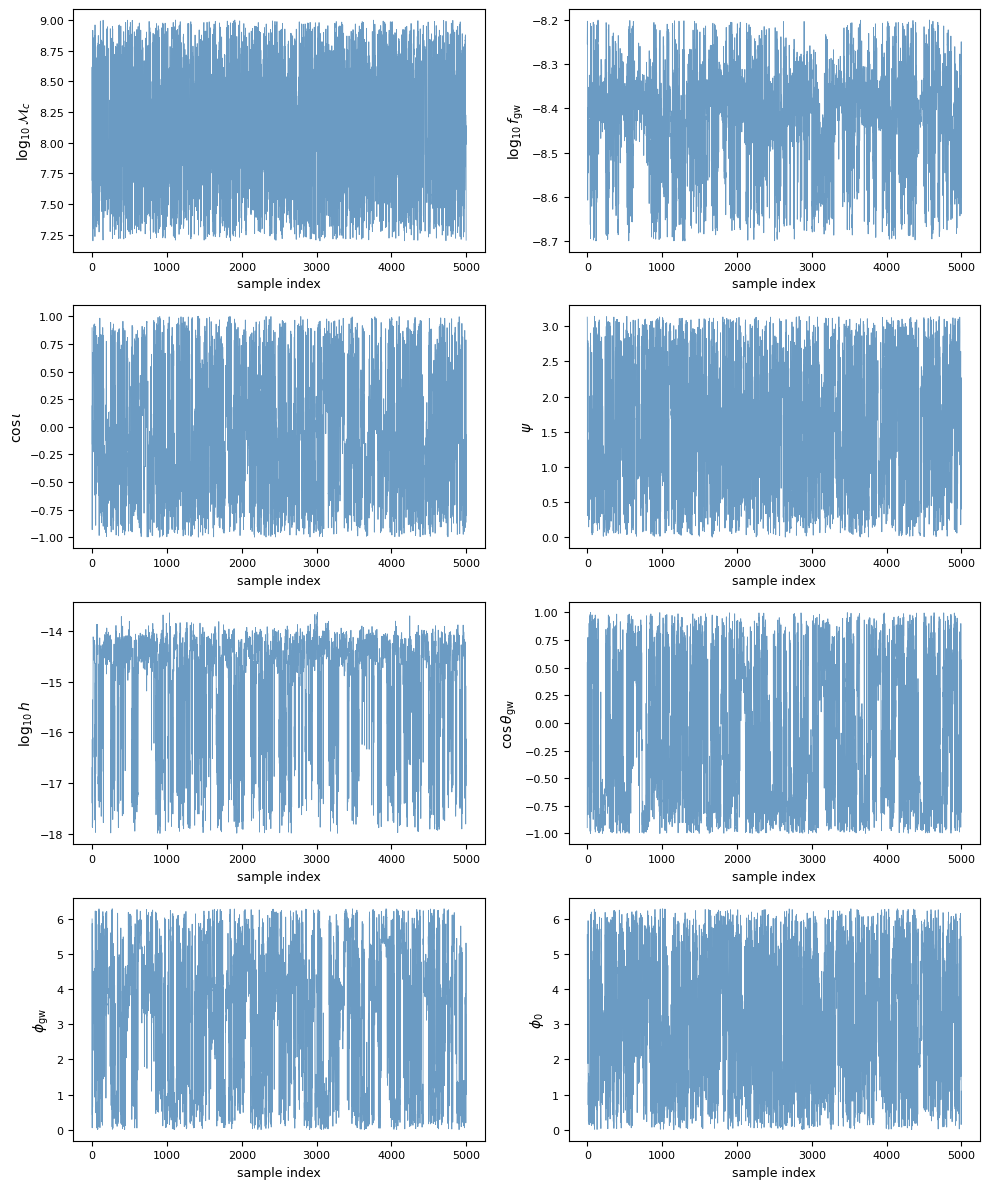

In [37]:
# trace plot
fig = plotter.trace(plotter.det_model_params())

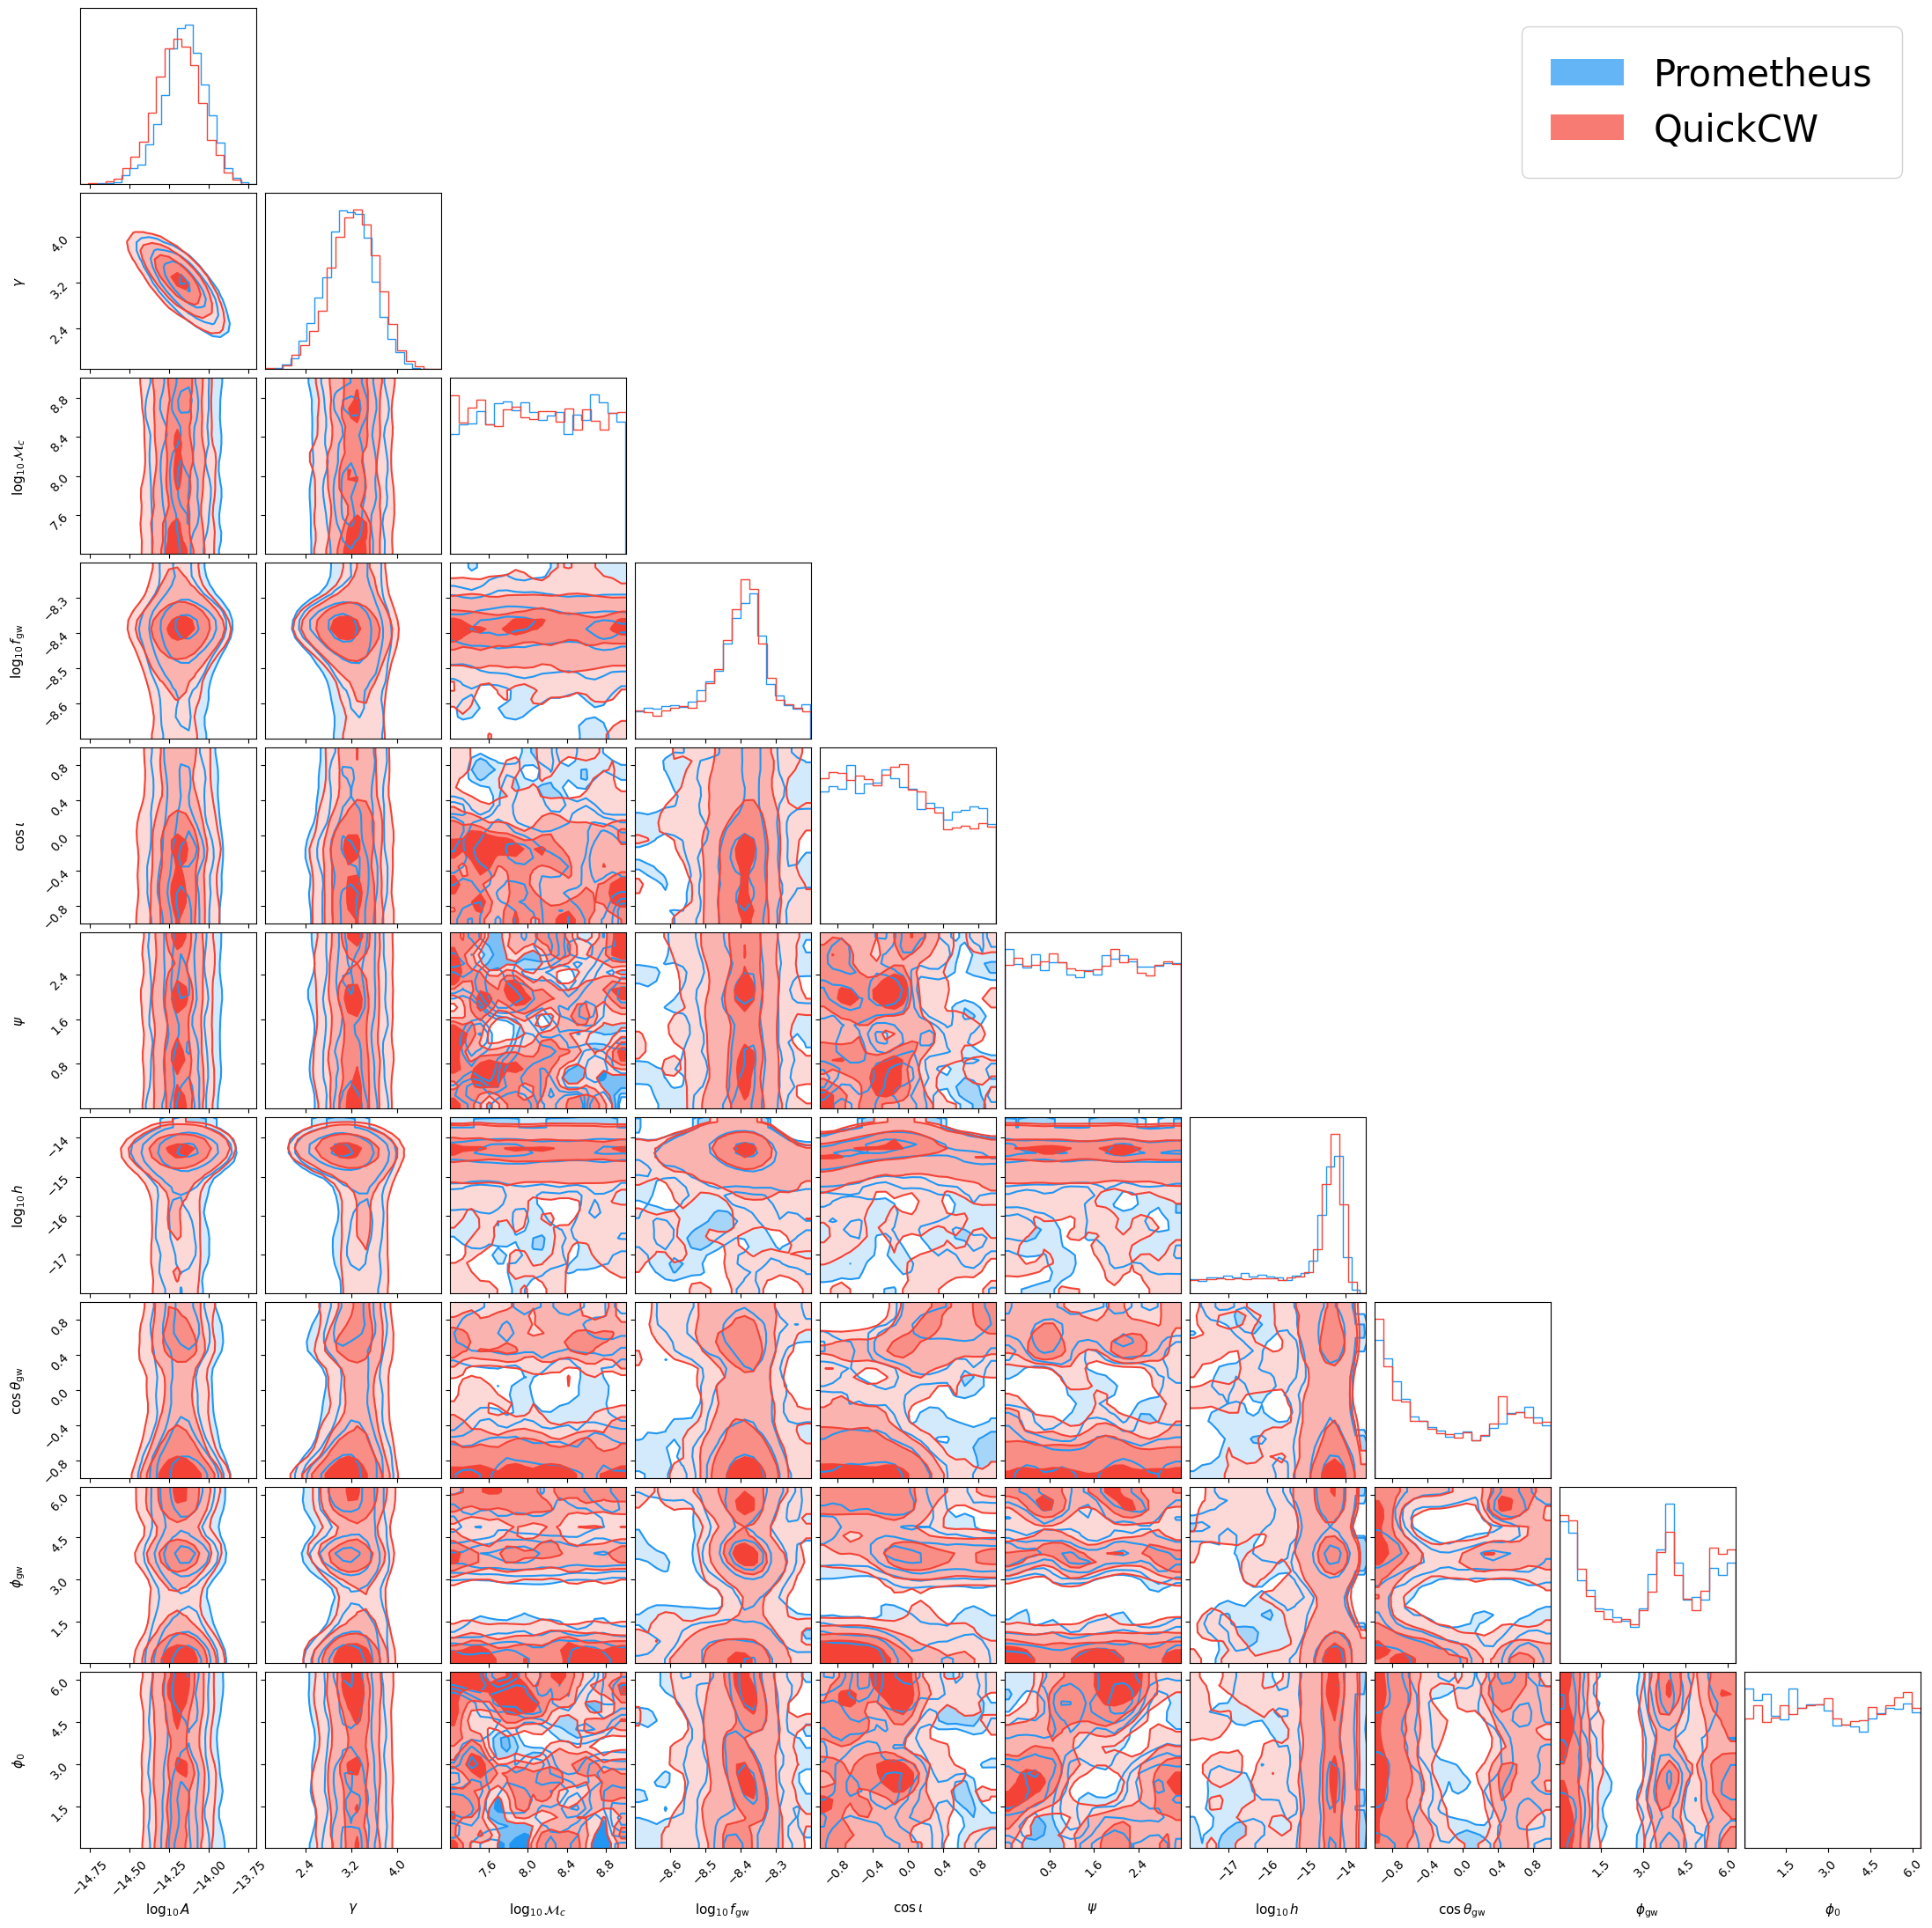

In [38]:
# GWB + CW recovery
fig = plotter.corner(plotter.gwb_model_params() + plotter.det_model_params(),
                     extra_samples=[quickCW_samples],
                     labels=['Prometheus', 'QuickCW'],
                     legend_fontsize=30,
                     bins=20)

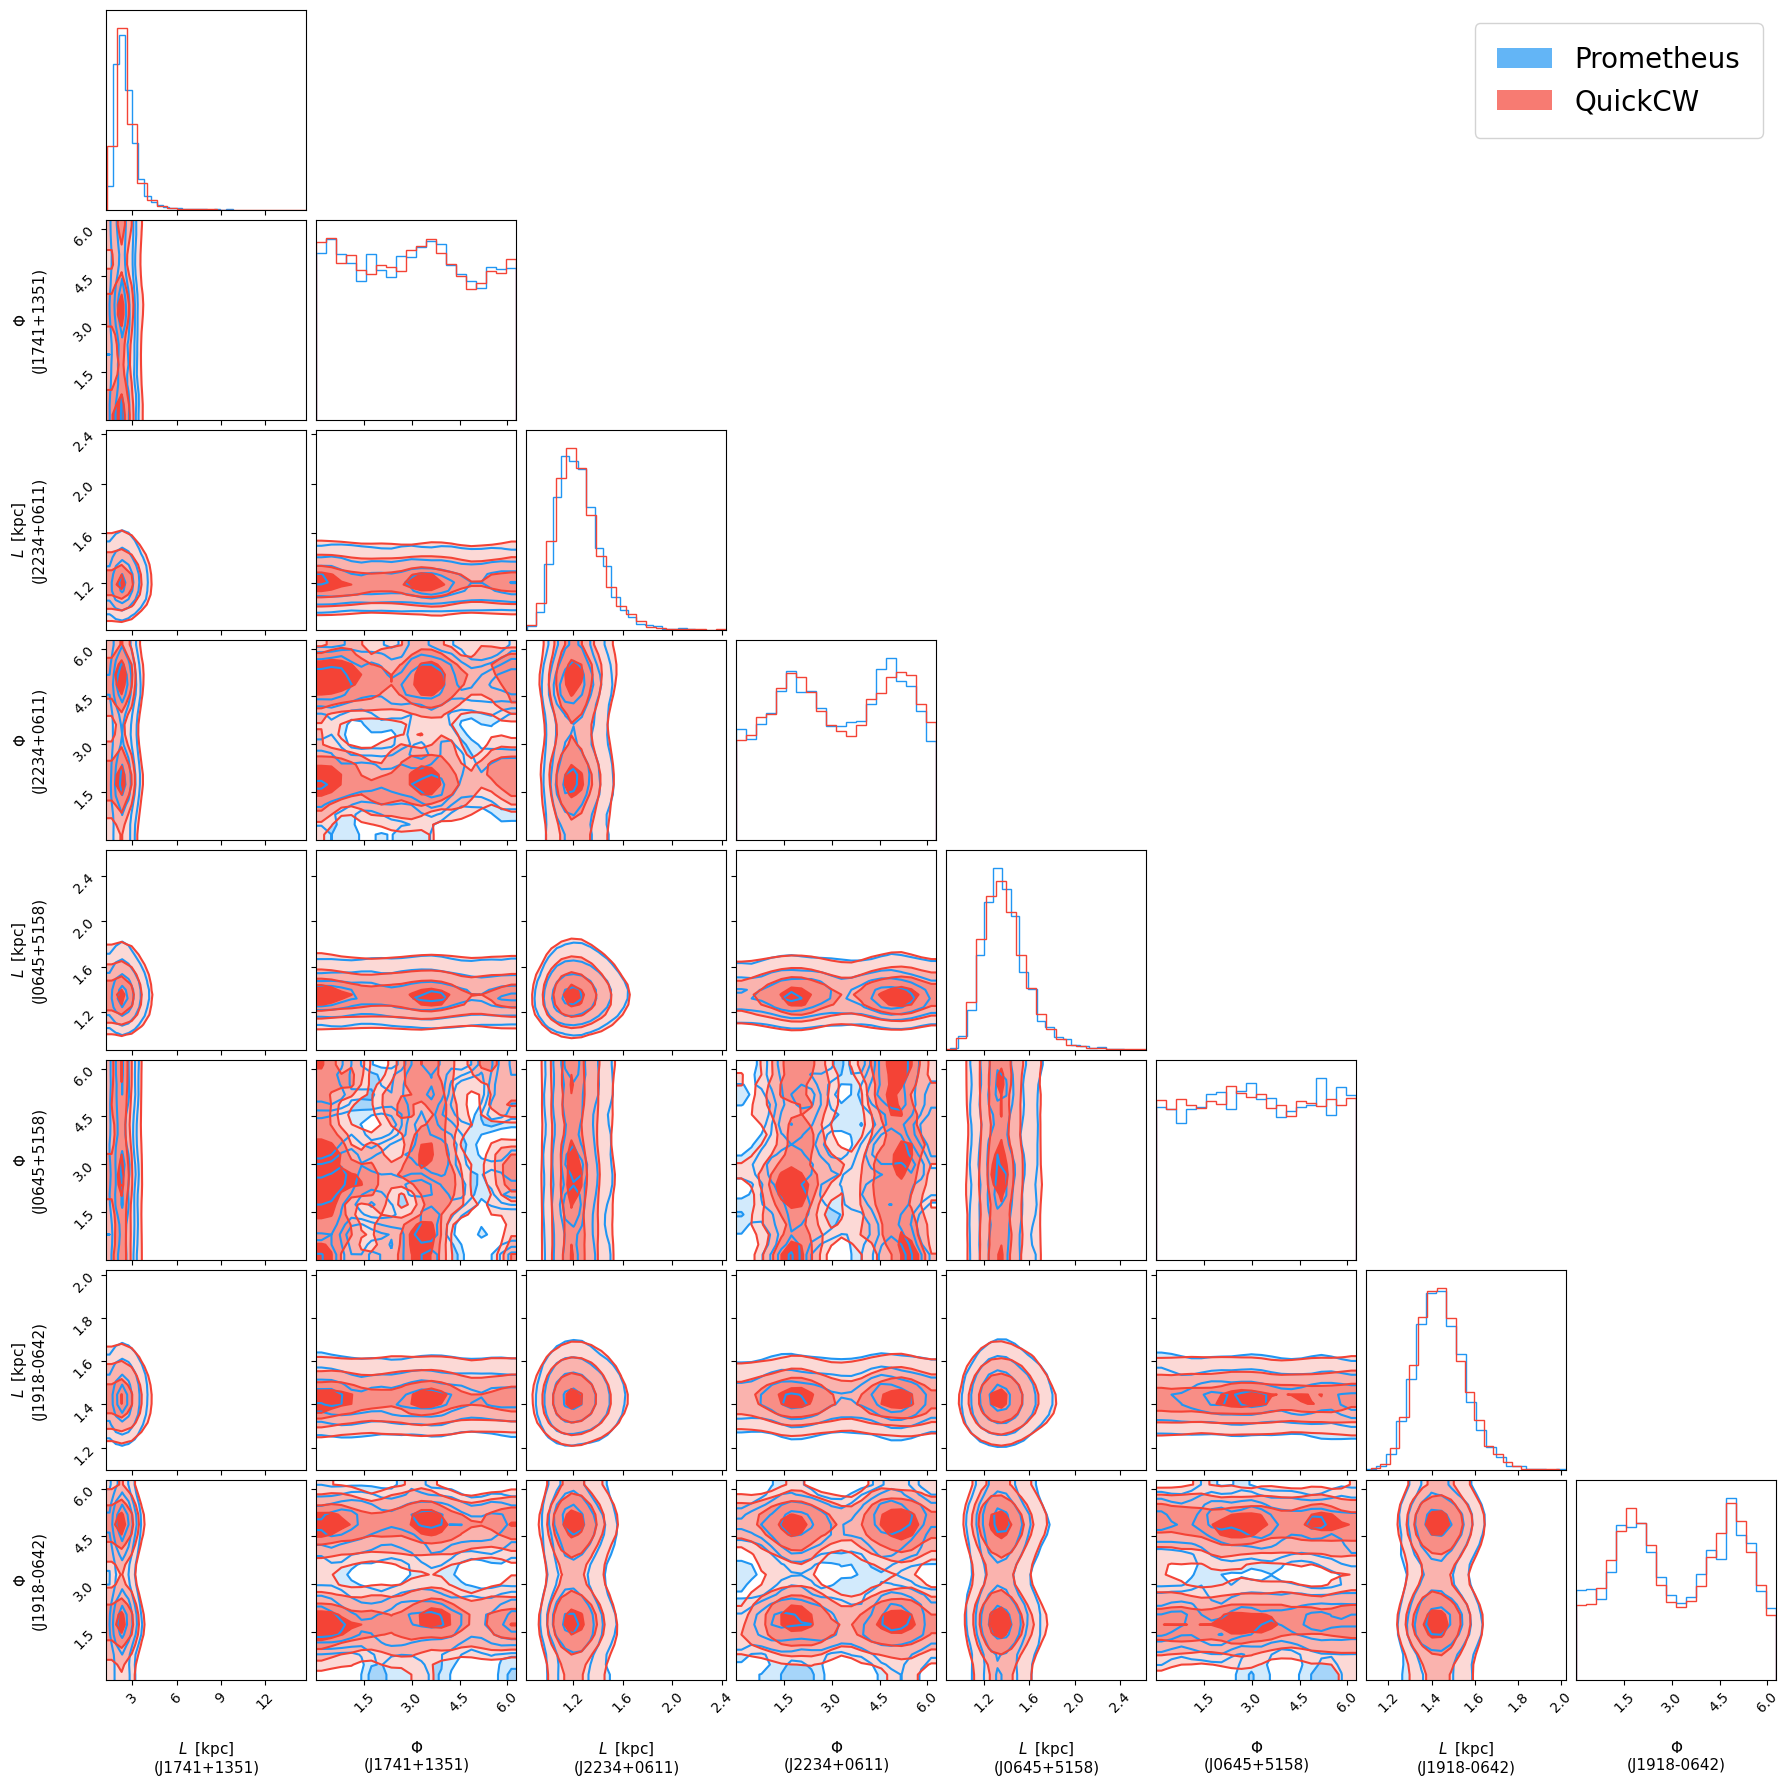

In [39]:
# pulsar distance + phase recovery
fig = plotter.corner(plotter.psr_dist_phase_params(np.r_[8:10, 55:57]),
                     extra_samples=[quickCW_samples],
                     labels=['Prometheus', 'QuickCW'],
                     legend_fontsize=20,
                     bins=20)